# KerrP2P Circular-Orbit Primary-Image Solver

This notebook computes the primary image of a pulsar on a circular orbit. The orbital phase `psi` is sampled on a fixed grid, and the effective observer azimuth is `phi_eff = phi_o - psi`.

The solver proceeds as follows:

1. At `psi = 0`, it automatically runs an all-branch sweep in `(r_c, log10|d|)` and selects the solution with the smallest `n_half` as the primary-image seed.
2. For the remaining orbital phases, it continues the previous solution in the image variables `(lambda, q)`. It first tries the previous branch signs `(nu_r, nu_theta)`, then tries the other sign combinations if they converge, and keeps the successful `(lambda, q)` root with the smallest `n_half`.
3. If that root solve fails, or if `n_half` changes by more than `max_nhalf_jump`, it first tries small local perturbations of the previous `(lambda, q)` seed. If those retries still do not give a trustworthy primary image, it runs the all-branch sweep again and selects the smallest-`n_half` solution.
4. The sweep also refines contour candidates with `scipy.optimize.root` in `(r_c, log10|d|)`. This catches primary images near the boundary of the valid ray-tracing domain where the built-in sweep polishing can miss a root.
5. Ray-tracing calls are protected against invalid trial parameters. If a trial point triggers a KerrP2P/Boost elliptic-function exception, the Python wrapper marks that trial or branch as invalid and continues instead of stopping the notebook.
6. After each fallback, the code reads out the winning `(lambda, q)` and continues around the orbit in `(lambda, q)` again.

The main user-facing cells are **User Input** and **Run The Example**. The other code cells define reusable helpers and normally do not need editing.


## Adjustable Parameters

The most important controls live in `SolverConfig`. The first group below has the largest effect on robustness and runtime.

- `sweep_refine_max_candidates`: number of contour candidates refined in Python after each branch sweep. This is often the most useful robustness knob. Larger values can recover roots missed by the built-in sweep ordering, but runtime increases because more candidates are polished with `scipy.optimize.root`.
- `max_nhalf_jump`: guard against accidentally continuing onto a discontinuous image branch. If a root, local retry, or sweep fallback changes `n_half` relative to the previous point by more than this value, the code rejects it or triggers fallback. Lower values are safer against discontinuous image jumps, but can reject a rapidly varying valid primary branch.
- `rc_size`, `d_size`: grid resolution of the all-branch `(r_c, log10|d|)` sweep. Increasing these resolves contour intersections better, at an approximately direct grid-cost increase.
- `log_abs_d_min`, `log_abs_d_max`: sampled range of `log10|d|`. Widen this range if the primary image is outside the current sweep window. A wider range can help difficult geometries, but it also spreads the same `d_size` grid points over a larger interval unless `d_size` is increased.
- `tol_sweep`, `cutoff`: lower-level controls for KerrP2P's built-in `sweep_rc_d_Float64`. The C++ sweep first marks grid cells where the `theta` and `phi` residual contours cross, pairs nearby contour cells, sorts candidates by their grid distance, and then runs Broyden polishing only on the first `cutoff` candidates. A polished candidate is accepted only if its final residual norm is below `tol_sweep`; the same tolerance is also used when removing duplicate built-in roots in `(r_c, log10|d|)`. Increasing `cutoff` can recover images farther down the candidate ordering but costs time; decreasing `tol_sweep` demands more accurate roots but may reject otherwise useful candidates.
- `tol_root`: tolerance for continuation in `(lambda, q)`. Tightening it improves residual accuracy but can make root finding less forgiving.
- `tol_sweep_refine`: tolerance for the Python-side `(r_c, log10|d|)` refinement.

Other useful controls:
- `local_perturb_enabled`: whether to try cheap local retries before the expensive all-branch sweep.
- `local_perturb_scales`: an array of relative step sizes used to perturb the previous `(lambda, q)` seed. For each `scale`, the code uses `delta_lam = scale * max(abs(lam0), 1)` and `delta_q = scale * max(abs(q0), 1)`. For example, if `(lam0, q0) = (6, 8)`, then `scale=1e-3` means steps of about `(0.006, 0.008)`. The default `(1e-4, 1e-3, 1e-2)` means the solver tries small, medium, and larger local neighborhoods.
- `local_perturb_patterns`: directions for those perturbations. The default tries `+/-lambda`, `+/-q`, and the four diagonal combinations for every scale in `local_perturb_scales`. Together, `3` scales and `8` patterns produce up to `24` local retry seeds.
- `log_progress`, `log_sweep_branches`: elapsed-time Python progress messages. `log_progress` shows high-level initialization, fallback, local retry, and sign-change messages. `log_sweep_branches` additionally prints the eight branch-level sweep summaries, which is useful for debugging but noisy for normal use.
- `quiet_sweep`: suppresses native sweep diagnostic output when `True`; Python progress logs still appear with elapsed times.

Invalid trial rays can occur during root solving, Python-side refinement, or the built-in branch sweep, especially near elliptic-integral domain boundaries. These exceptions are caught in the notebook wrapper: the affected trial point returns a large residual, and an affected built-in sweep branch is skipped with a progress message.

Primary fallback means that the code did not trust the direct `(lambda, q)` continuation at that phase, so it fell back to the all-branch sweep and again selected the smallest-`n_half` image.


## Program Definitions

These cells import dependencies and define reusable data structures, geometry helpers, root residuals, continuation logic, and all-branch sweep fallback. They are implementation details and normally do not need editing.


### 1. Imports and Utilities

Imports, path setup, sign helpers, angular helpers, logging, and output-suppression utilities.


In [1]:
import os
import ctypes
import contextlib
from time import perf_counter
from dataclasses import dataclass
from types import SimpleNamespace

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-kerrp2p")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

import pykerrp2p as rt


NOTEBOOK_T0 = perf_counter()


def reset_elapsed_timer():
    global NOTEBOOK_T0
    NOTEBOOK_T0 = perf_counter()


def format_elapsed(seconds=None):
    if seconds is None:
        seconds = perf_counter() - NOTEBOOK_T0
    seconds = int(round(seconds))
    minutes, secs = divmod(seconds, 60)
    return f"{minutes:02d}:{secs:02d}"


def log(message):
    print(f"[{format_elapsed()}] {message}")




def rc_range(a):
    return (
        4 * np.square(np.cos(np.arccos(-a) / 3) + 1e-10),
        4 * np.square(np.cos(np.arccos(a) / 3)) - 1e-10,
    )


def sign_from_num(x):
    return rt.Sign.POSITIVE if x > 0 else rt.Sign.NEGATIVE


def sign_to_num(x):
    if x == rt.Sign.POSITIVE:
        return 1
    if x == rt.Sign.NEGATIVE:
        return -1
    return np.nan


def normalize_phi(phi):
    return float(phi % (2 * np.pi))


def conserve_to_ob(a, lam, eta, theta_o, nu_theta_o):
    alpha = -lam / np.sin(theta_o)
    beta2 = eta + a**2 * np.cos(theta_o) ** 2 - lam**2 / np.tan(theta_o) ** 2
    beta = nu_theta_o * np.sqrt(max(beta2, 0.0))
    return float(alpha), float(beta)


@contextlib.contextmanager
def suppress_native_stdout(enabled=True):
    if not enabled:
        yield
        return
    fds = (1, 2)
    saved_fds = [os.dup(fd) for fd in fds]
    try:
        with open(os.devnull, "w") as devnull:
            for fd in fds:
                os.dup2(devnull.fileno(), fd)
            yield
    finally:
        ctypes.CDLL(None).fflush(None)
        for fd, saved_fd in zip(fds, saved_fds):
            os.dup2(saved_fd, fd)
            os.close(saved_fd)


### 2. Configuration Objects

Dataclasses for the orbit geometry and solver controls.


In [ ]:
@dataclass
class OrbitConfig:
    # Kerr spin and source/observer geometry.
    a: float
    r_s: float
    theta_s: float
    r_o: float
    theta_o: float
    phi_o: float

    # Number of equal pulsar-phase intervals on the circular orbit.
    n_pts: int = 120


@dataclass
class SolverConfig:
    # Continuation solve in (lambda, q). Smaller values are stricter but may cost more iterations.
    tol_root: float = 1e-8

    # Built-in rc-d sweep tolerance and grid size. Larger grids are slower but resolve contours better.
    tol_sweep: float = 1e-6
    rc_size: int = 1000
    d_size: int = 1000

    # Contour-search cutoff passed to KerrP2P's rc-d sweep.
    cutoff: int = 50

    # Local perturbation retries in (lambda, q), used before the expensive all-branch sweep.
    local_perturb_enabled: bool = True
    local_perturb_scales: tuple = (1e-4, 1e-3, 1e-2)
    local_perturb_patterns: tuple = ((1, 0), (-1, 0), (0, 1), (0, -1), (1, 1), (1, -1), (-1, 1), (-1, -1))

    # Python-side refinement of rc-d contour candidates. This improves robustness near valid-domain boundaries.
    tol_sweep_refine: float = 1e-9
    sweep_refine_max_candidates: int = 1000

    # Sweep range for log10(abs(d)). Widen this if the primary image lies outside the sampled d range.
    log_abs_d_min: float = -3.0
    log_abs_d_max: float = 3.0

    # If continuation changes n_half by more than this amount, treat it as a possible image jump and run sweep fallback.
    max_nhalf_jump: float = 0.1

    # Timestamped Python progress messages. Branch-level sweep logging helps monitor runtime.
    log_progress: bool = True
    log_sweep_branches: bool = False

    # Suppress verbose native messages during all-branch sweeps.
    quiet_sweep: bool = True


### 3. Lambda-Q Continuation

Ray wrappers, residuals, branch-sign trials, local perturbation retries, and row construction for `(lambda, q)` continuation.


In [3]:
def make_params_lamq(cfg, nu_r, nu_theta, lam, q, calc_t_f=True):
    pars = rt.ForwardRayTracingParamsFloat64()
    pars.a = float(cfg.a)
    pars.r_s = float(cfg.r_s)
    pars.theta_s = float(cfg.theta_s)
    pars.r_o = float(cfg.r_o)
    pars.nu_r = sign_from_num(nu_r)
    pars.nu_theta = sign_from_num(nu_theta)
    pars.lam = float(lam)
    pars.q = float(q)
    pars.calc_t_f = bool(calc_t_f)
    pars.print_args_error = False
    return pars


def calc_ray_lamq(cfg, lam, q, nu_r, nu_theta, calc_t_f=False):
    if not (np.isfinite(lam) and np.isfinite(q) and q > 0):
        return None, None
    pars = make_params_lamq(cfg, nu_r, nu_theta, lam, q, calc_t_f=calc_t_f)
    try:
        with suppress_native_stdout(True):
            ray = rt.calc_ray_Float64(pars)
    except Exception:
        return None, pars
    if ray.ray_status != rt.RayStatus.NORMAL:
        return None, pars
    return ray, pars


def residual_lamq(x, cfg, phi_eff, nu_r, nu_theta):
    lam, q = float(x[0]), float(x[1])
    ray, _ = calc_ray_lamq(cfg, lam, q, nu_r, nu_theta, calc_t_f=False)
    if ray is None:
        return np.array([1e6, 1e6], dtype=float)
    return np.array([
        ray.theta_f - cfg.theta_o,
        np.sin((ray.phi_f - phi_eff) / 2.0),
    ], dtype=float)


def row_from_ray(cfg, psi, phi_eff, ray, pars, method, branch_retried=False, fail_reason=""):
    nu_r = sign_to_num(pars.nu_r)
    nu_theta = sign_to_num(pars.nu_theta)
    nu_theta_o = ((-1) ** int(ray.m)) * int(nu_theta)
    alpha, beta = conserve_to_ob(cfg.a, ray.lam, ray.eta, cfg.theta_o, nu_theta_o)
    row = dict(
        success=True,
        psi=float(psi),
        phi_eff=float(phi_eff),
        phi_eff_mod=normalize_phi(phi_eff),
        method=method,
        branch_retried=bool(branch_retried),
        fail_reason=fail_reason,
        nu_r=int(nu_r),
        nu_theta=int(nu_theta),
        lam=float(ray.lam),
        eta=float(ray.eta),
        q=float(np.sqrt(max(ray.eta, 0.0))),
        m=int(ray.m),
        n_half=float(ray.n_half),
        alpha=alpha,
        beta=beta,
        theta_f=float(ray.theta_f),
        phi_f=float(ray.phi_f),
        t_f=float(ray.t_f),
    )
    if hasattr(ray, "rc"):
        row["rc"] = float(ray.rc)
    if hasattr(ray, "log_abs_d"):
        row["log_abs_d"] = float(ray.log_abs_d)
    return row


def branch_trials(nu_r, nu_theta):
    first = (int(nu_r), int(nu_theta))
    trials = [first]
    for item in [(-first[0], first[1]), (first[0], -first[1]), (-first[0], -first[1])]:
        if item not in trials:
            trials.append(item)
    return trials


def lamq_guesses_from_seed(seed, scfg):
    base = np.array([seed["lam"], seed["q"]], dtype=float)
    guesses = [base]
    if not scfg.local_perturb_enabled:
        return guesses

    lam_scale = max(abs(base[0]), 1.0)
    q_scale = max(abs(base[1]), 1.0)
    for scale in scfg.local_perturb_scales:
        for dlam, dq in scfg.local_perturb_patterns:
            x = base + np.array([dlam * scale * lam_scale, dq * scale * q_scale], dtype=float)
            if np.isfinite(x[0]) and np.isfinite(x[1]) and x[1] > 0:
                guesses.append(x)
    return guesses


def collect_lamq_root_candidates(cfg, seed, phi_eff, guesses, tol):
    failures = []
    candidates = []

    for j, x0 in enumerate(guesses):
        for i, (nu_r, nu_theta) in enumerate(branch_trials(seed["nu_r"], seed["nu_theta"])):
            sol = optimize.root(lambda x: residual_lamq(x, cfg, phi_eff, nu_r, nu_theta), x0, method="hybr", tol=tol)
            resid = residual_lamq(sol.x, cfg, phi_eff, nu_r, nu_theta)
            resid_norm = float(np.linalg.norm(resid))
            if sol.success and np.isfinite(resid_norm) and resid_norm <= 10 * tol:
                ray, pars = calc_ray_lamq(cfg, sol.x[0], sol.x[1], nu_r, nu_theta, calc_t_f=True)
                if ray is not None:
                    duplicate = any(
                        abs(ray.lam - old_ray.lam) < 10 * tol and abs(np.sqrt(ray.eta) - np.sqrt(old_ray.eta)) < 10 * tol
                        for old_ray, _, _, _ in candidates
                    )
                    if not duplicate:
                        candidates.append((ray, pars, i > 0, j > 0))
                    continue
            if j == 0:
                failures.append(f"({nu_r:+d},{nu_theta:+d}): {sol.message}; residual={resid_norm:.3e}")

    return candidates, failures


def find_root_lamq_with_branch_retries(cfg, seed, phi_eff, tol):
    guesses = [np.array([seed["lam"], seed["q"]], dtype=float)]
    candidates, failures = collect_lamq_root_candidates(cfg, seed, phi_eff, guesses, tol)
    if candidates:
        ray, pars, branch_retried, seed_perturbed = min(candidates, key=lambda item: float(item[0].n_half))
        return ray, pars, branch_retried, ""
    return None, None, True, "; ".join(failures)


def find_root_lamq_with_local_perturbations(cfg, seed, phi_eff, scfg):
    guesses = lamq_guesses_from_seed(seed, scfg)[1:]
    if not guesses:
        return None, None, False, "local perturbation disabled"

    candidates, failures = collect_lamq_root_candidates(cfg, seed, phi_eff, guesses, scfg.tol_root)
    if candidates:
        ray, pars, branch_retried, seed_perturbed = min(candidates, key=lambda item: float(item[0].n_half))
        return ray, pars, branch_retried or seed_perturbed, ""
    return None, None, True, f"local perturbation found no root from {len(guesses)} guesses"


### 4. Rc-D Sweep Fallback and Orbit Driver

All-branch `(r_c, log10|d|)` sweep fallback, Python-side candidate refinement, and the circular-orbit driver.


In [4]:
def sign_change_roots(delta, x_list, y_list, valid=None):
    roots = []
    for i in range(1, len(y_list)):
        for j in range(1, len(x_list)):
            if valid is not None and not (valid[i, j] and valid[i, j - 1] and valid[i - 1, j]):
                continue
            vals = (delta[i, j], delta[i, j - 1], delta[i - 1, j])
            if all(np.isfinite(v) for v in vals):
                if np.sign(vals[0]) * np.sign(vals[1]) <= 0 or np.sign(vals[0]) * np.sign(vals[2]) <= 0:
                    roots.append((i, j))
    return roots


def refine_lamq_candidate(cfg, phi_eff, lam0, q0, nu_r, nu_theta, tol):
    sol = optimize.root(
        lambda x: residual_lamq(x, cfg, phi_eff, nu_r, nu_theta),
        np.array([lam0, q0], dtype=float),
        method="hybr",
        tol=tol,
    )
    resid = residual_lamq(sol.x, cfg, phi_eff, nu_r, nu_theta)
    resid_norm = float(np.linalg.norm(resid))
    if not (sol.success and np.isfinite(resid_norm) and resid_norm <= 10 * tol):
        return None
    ray, pars = calc_ray_lamq(cfg, sol.x[0], sol.x[1], nu_r, nu_theta, calc_t_f=True)
    if ray is None:
        return None
    return ray, pars


def make_params_rcd(cfg, nu_r, nu_theta, d_sign, rc=None, log_abs_d=None, calc_t_f=False):
    pars = rt.ForwardRayTracingParamsFloat64()
    pars.a = float(cfg.a)
    pars.r_s = float(cfg.r_s)
    pars.theta_s = float(cfg.theta_s)
    pars.r_o = float(cfg.r_o)
    pars.nu_r = sign_from_num(nu_r)
    pars.nu_theta = sign_from_num(nu_theta)
    pars.d_sign = sign_from_num(d_sign)
    if rc is not None:
        pars.rc = float(rc)
    if log_abs_d is not None:
        pars.log_abs_d = float(log_abs_d)
    pars.calc_t_f = bool(calc_t_f)
    pars.print_args_error = False
    return pars


def ray_from_rcd(cfg, x, nu_r, nu_theta, d_sign, calc_t_f=False):
    rc, log_abs_d = float(x[0]), float(x[1])
    pars = make_params_rcd(cfg, nu_r, nu_theta, d_sign, rc, log_abs_d, calc_t_f=calc_t_f)
    try:
        if not pars.rc_d_to_lambda_q():
            return None, pars
        with suppress_native_stdout(True):
            ray = rt.calc_ray_Float64(pars)
    except Exception:
        return None, pars
    if ray.ray_status != rt.RayStatus.NORMAL:
        return None, pars
    return ray, pars


def attach_rcd_ray(ray, rc, log_abs_d):
    return SimpleNamespace(
        n_half=float(ray.n_half),
        rc=float(rc),
        log_abs_d=float(log_abs_d),
        lam=float(ray.lam),
        eta=float(ray.eta),
        m=int(ray.m),
        theta_f=float(ray.theta_f),
        phi_f=float(ray.phi_f),
        t_f=float(ray.t_f),
    )


def residual_rcd(x, cfg, phi_eff, nu_r, nu_theta, d_sign):
    ray, _ = ray_from_rcd(cfg, x, nu_r, nu_theta, d_sign, calc_t_f=False)
    if ray is None:
        return np.array([1e6, 1e6], dtype=float)
    return np.array([
        ray.theta_f - cfg.theta_o,
        np.sin((ray.phi_f - phi_eff) / 2.0),
    ], dtype=float)


def unique_rcd_candidates(points, tol=1e-12):
    out = []
    for p in points:
        if len(p) != 2 or not np.all(np.isfinite(p)):
            continue
        p = np.asarray(p, dtype=float)
        if not any(np.linalg.norm(p - q) < tol for q in out):
            out.append(p)
    return out


def scipy_refine_rcd_candidates(cfg, phi_eff, data, nu_r, nu_theta, d_sign, scfg):
    candidates = []
    max_candidates = scfg.sweep_refine_max_candidates
    if len(data.theta_roots_closest):
        candidates.extend([p for p in data.theta_roots_closest[:max_candidates]])
    if len(data.phi_roots):
        candidates.extend([p for p in data.phi_roots[:max_candidates]])
    if len(data.theta_roots):
        candidates.extend([p for p in data.theta_roots[:max_candidates]])
    candidates = unique_rcd_candidates(candidates)

    roots = []
    for x0 in candidates:
        sol = optimize.root(
            lambda x: residual_rcd(x, cfg, phi_eff, nu_r, nu_theta, d_sign),
            x0,
            method="hybr",
            tol=scfg.tol_sweep_refine,
        )
        resid = residual_rcd(sol.x, cfg, phi_eff, nu_r, nu_theta, d_sign)
        resid_norm = float(np.linalg.norm(resid))
        if not (sol.success and np.isfinite(resid_norm) and resid_norm < max(1e-6, 10 * scfg.tol_sweep)):
            continue
        ray, pars = ray_from_rcd(cfg, sol.x, nu_r, nu_theta, d_sign, calc_t_f=True)
        if ray is None:
            continue
        ray = attach_rcd_ray(ray, sol.x[0], sol.x[1])
        duplicate = any(
            abs(ray.rc - old_ray.rc) < 1e-7 and abs(ray.log_abs_d - old_ray.log_abs_d) < 1e-7
            for old_ray, _ in roots
        )
        if not duplicate:
            roots.append((ray, pars))
    return roots


def is_duplicate_solution(ray, solutions, tol):
    q = np.sqrt(max(ray.eta, 0.0))
    return any(
        abs(ray.lam - old_ray.lam) < tol and abs(q - np.sqrt(max(old_ray.eta, 0.0))) < tol
        for _, old_ray, _, _ in solutions
    )


def all_branch_primary_sweep_rcd(cfg, phi_eff, scfg, label="all-branch sweep"):
    rc_l, rc_h = rc_range(cfg.a)
    rc_list = np.linspace(rc_l, rc_h, scfg.rc_size)
    lgd_list = np.linspace(scfg.log_abs_d_min, scfg.log_abs_d_max, scfg.d_size)
    solutions = []
    n_builtin = 0
    n_refined = 0
    t0 = perf_counter()
    if scfg.log_progress:
        log(f"{label}: start at phi_eff={phi_eff:.12g}; grid={scfg.rc_size}x{scfg.d_size}, log_abs_d=[{scfg.log_abs_d_min}, {scfg.log_abs_d_max}]")

    for nu_r in [-1, 1]:
        for nu_theta in [-1, 1]:
            for d_sign in [-1, 1]:
                pars = make_params_rcd(cfg, nu_r, nu_theta, d_sign, calc_t_f=True)
                try:
                    with suppress_native_stdout(scfg.quiet_sweep):
                        data = rt.sweep_rc_d_Float64(
                            pars,
                            cfg.theta_o,
                            normalize_phi(phi_eff),
                            rc_list,
                            lgd_list,
                            scfg.cutoff,
                            scfg.tol_sweep,
                        )
                except Exception as exc:
                    if scfg.log_progress and scfg.log_sweep_branches:
                        log(
                            f"{label}: branch (nu_r={nu_r:+d}, nu_theta={nu_theta:+d}, d_sign={d_sign:+d}) skipped: "
                            f"{type(exc).__name__}: {exc}"
                        )
                    continue

                for ray in data.results:
                    if not is_duplicate_solution(ray, solutions, scfg.tol_sweep):
                        solutions.append((float(ray.n_half), ray, pars, "builtin"))
                        n_builtin += 1

                refined_here = 0
                for ray, refined_pars in scipy_refine_rcd_candidates(cfg, phi_eff, data, nu_r, nu_theta, d_sign, scfg):
                    if not is_duplicate_solution(ray, solutions, max(scfg.tol_sweep, 1e-7)):
                        solutions.append((float(ray.n_half), ray, refined_pars, "scipy_refined"))
                        n_refined += 1
                        refined_here += 1

                if scfg.log_progress and scfg.log_sweep_branches:
                    log(
                        f"{label}: branch (nu_r={nu_r:+d}, nu_theta={nu_theta:+d}, d_sign={d_sign:+d}) "
                        f"built-in={len(data.results)}, refined_new={refined_here}, total_unique={len(solutions)}, "
                        f"elapsed={format_elapsed(perf_counter() - t0)}"
                    )

    if not solutions:
        if scfg.log_progress:
            log(f"{label}: no image found; elapsed={format_elapsed(perf_counter() - t0)}")
        return None, "all-branch rc-d sweep found no image"

    _, ray, pars, source = min(solutions, key=lambda x: x[0])
    # Continue afterward in lambda-q variables; pars carries the winning branch signs.
    pars.lam = float(ray.lam)
    pars.q = float(np.sqrt(max(ray.eta, 0.0)))
    pars.calc_t_f = True
    if scfg.log_progress:
        log(
            f"{label}: selected source={source}, n_half={ray.n_half:.6g}, "
            f"lam={ray.lam:.6g}, q={np.sqrt(max(ray.eta, 0.0)):.6g}, "
            f"solutions={len(solutions)} (built-in={n_builtin}, refined={n_refined}), "
            f"elapsed={format_elapsed(perf_counter() - t0)}"
        )
    return (ray, pars, len(solutions), n_builtin, n_refined, source), ""

def solve_at_phi(cfg, seed, psi, phi_eff, scfg):
    ray, pars, branch_retried, fail_reason = find_root_lamq_with_branch_retries(cfg, seed, phi_eff, scfg.tol_root)
    needs_sweep = False
    fallback_reason = ""
    if ray is None:
        needs_sweep = True
        fallback_reason = "root failed"
    elif "n_half" in seed:
        jump = abs(float(ray.n_half) - float(seed["n_half"]))
        if jump > scfg.max_nhalf_jump:
            needs_sweep = True
            fallback_reason = f"n_half jump: {float(seed['n_half']):.6g} -> {float(ray.n_half):.6g}"

    if ray is not None and not needs_sweep:
        return row_from_ray(cfg, psi, phi_eff, ray, pars, "root_lamq", branch_retried, fail_reason)

    if scfg.local_perturb_enabled:
        if scfg.log_progress:
            log(f"local perturbation: start at psi={psi:.6f}, phi_eff={phi_eff:.12g}; reason={fallback_reason}")
        local_ray, local_pars, local_retried, local_reason = find_root_lamq_with_local_perturbations(cfg, seed, phi_eff, scfg)
        if local_ray is not None:
            local_jump = abs(float(local_ray.n_half) - float(seed.get("n_half", local_ray.n_half)))
            if local_jump <= scfg.max_nhalf_jump:
                if scfg.log_progress:
                    log(
                        f"local perturbation: accepted n_half={local_ray.n_half:.6g}, "
                        f"lam={local_ray.lam:.6g}, q={np.sqrt(max(local_ray.eta, 0.0)):.6g}"
                    )
                row = row_from_ray(cfg, psi, phi_eff, local_ray, local_pars, "root_lamq_local_perturb", local_retried, fail_reason)
                row["primary_guard_triggered"] = bool(needs_sweep)
                row["fallback_reason"] = fallback_reason
                row["local_perturbation_used"] = True
                return row
            if scfg.log_progress:
                log(
                    f"local perturbation: rejected by n_half guard "
                    f"{float(seed.get('n_half', np.nan)):.6g} -> {local_ray.n_half:.6g}"
                )
        elif scfg.log_progress:
            log(f"local perturbation: no accepted root ({local_reason})")

    fallback, sweep_reason = all_branch_primary_sweep_rcd(
        cfg,
        phi_eff,
        scfg,
        label=f"primary fallback psi={psi:.6f}",
    )
    if fallback is None:
        if ray is not None:
            row = row_from_ray(cfg, psi, phi_eff, ray, pars, "root_lamq_guarded", branch_retried, fail_reason + " | primary sweep failed: " + sweep_reason)
            row["primary_guard_triggered"] = bool(needs_sweep)
            row["fallback_reason"] = fallback_reason
            return row
        return dict(
            success=False,
            psi=float(psi),
            phi_eff=float(phi_eff),
            phi_eff_mod=normalize_phi(phi_eff),
            method="failed",
            fail_reason=fail_reason + " | " + sweep_reason,
            fallback_reason=fallback_reason,
        )

    ray, pars, n_sweep_solutions, n_builtin, n_refined, sweep_source = fallback
    if "n_half" in seed:
        sweep_jump = abs(float(ray.n_half) - float(seed["n_half"]))
        if sweep_jump > scfg.max_nhalf_jump:
            reason = (
                f"primary sweep rejected by n_half guard: "
                f"{float(seed['n_half']):.6g} -> {float(ray.n_half):.6g}"
            )
            if scfg.log_progress:
                log(reason)
            return dict(
                success=False,
                psi=float(psi),
                phi_eff=float(phi_eff),
                phi_eff_mod=normalize_phi(phi_eff),
                method="failed",
                fail_reason=fail_reason + " | " + reason,
                fallback_reason=fallback_reason,
                primary_guard_triggered=True,
            )

    method = "all_branch_sweep_rcd_refined" if sweep_source == "scipy_refined" else "all_branch_sweep_rcd"
    row = row_from_ray(cfg, psi, phi_eff, ray, pars, method, True, fail_reason)
    row["n_sweep_solutions"] = int(n_sweep_solutions)
    row["n_sweep_builtin_solutions"] = int(n_builtin)
    row["n_sweep_refined_solutions"] = int(n_refined)
    row["sweep_source"] = sweep_source
    row["primary_guard_triggered"] = bool(needs_sweep)
    row["fallback_reason"] = fallback_reason
    return row

def initialize_primary_seed(cfg, scfg):
    fallback, sweep_reason = all_branch_primary_sweep_rcd(cfg, cfg.phi_o, scfg, label="initial psi=0 primary sweep")
    if fallback is None:
        return None, sweep_reason

    ray, pars, n_sweep_solutions, n_builtin, n_refined, sweep_source = fallback
    method = "initial_sweep_rcd_refined" if sweep_source == "scipy_refined" else "initial_sweep_rcd"
    row = row_from_ray(cfg, 0.0, cfg.phi_o, ray, pars, method, True, "")
    row["n_sweep_solutions"] = int(n_sweep_solutions)
    row["n_sweep_builtin_solutions"] = int(n_builtin)
    row["n_sweep_refined_solutions"] = int(n_refined)
    row["sweep_source"] = sweep_source
    row["primary_guard_triggered"] = False
    row["fallback_reason"] = "automatic psi=0 primary initialization"
    seed = dict(
        nu_r=row["nu_r"],
        nu_theta=row["nu_theta"],
        lam=row["lam"],
        q=row["q"],
        n_half=row["n_half"],
    )
    return (row, seed), ""


def sweep_orbit(cfg, scfg=None, verbose=True):
    if scfg is None:
        scfg = SolverConfig()
    reset_elapsed_timer()
    psi_list = 2 * np.pi * np.arange(cfg.n_pts + 1) / cfg.n_pts
    initialized, sweep_reason = initialize_primary_seed(cfg, scfg)
    if initialized is None:
        return [dict(
            success=False,
            psi=0.0,
            phi_eff=float(cfg.phi_o),
            phi_eff_mod=normalize_phi(cfg.phi_o),
            method="failed",
            fail_reason="automatic psi=0 primary initialization failed: " + sweep_reason,
            fallback_reason="automatic psi=0 primary initialization",
        )]

    first_row, seed = initialized
    rows = [first_row]
    if verbose:
        log(
            f"  0/{len(psi_list)-1}: psi=0.000000, phi_eff={cfg.phi_o:.6f}, "
            f"method={first_row['method']}, success=True, n_half={first_row['n_half']:.6g}, "
            f"lam={first_row['lam']:.6g}, q={first_row['q']:.6g}"
        )

    for k, psi in enumerate(psi_list[1:], start=1):
        phi_eff = cfg.phi_o - psi
        old_signs = (seed["nu_r"], seed["nu_theta"])
        row = solve_at_phi(cfg, seed, psi, phi_eff, scfg)
        rows.append(row)

        if row.get("success", False):
            new_signs = (row["nu_r"], row["nu_theta"])
            if scfg.log_progress and new_signs != old_signs:
                log(
                    f"Branch sign changed at phi_eff = {phi_eff:.12g}: "
                    f"{{nu_r, nu_theta}} = {old_signs} -> {new_signs}; "
                    f"method={row['method']}, n_half={row['n_half']:.6g}"
                )
            seed.update(
                nu_r=row["nu_r"],
                nu_theta=row["nu_theta"],
                lam=row["lam"],
                q=row["q"],
                n_half=row["n_half"],
            )

        if verbose and (row["method"] != "root_lamq" or k % 20 == 0 or k == len(psi_list) - 1):
            reason = row.get("fallback_reason", "")
            reason_text = f", reason={reason}" if reason else ""
            log(
                f"{k:3d}/{len(psi_list)-1}: psi={psi:.6f}, phi_eff={phi_eff:.6f}, "
                f"method={row['method']}, success={row.get('success', False)}, "
                f"n_half={row.get('n_half', np.nan):.6g}" + reason_text
            )

    return rows


## User Input

Edit this cell to define the pulsar geometry, observer position, and solver controls. Angles are in radians.

In [69]:
# Edit this cell for a new circular-orbit pulsar problem.
# Angles are in radians. The psi = 0 primary seed is found automatically by sweep.

case1 = OrbitConfig(
    a=0.8,
    r_s=10.0,
    theta_s=89.9 * np.pi / 180,
    r_o=1000.0,
    theta_o=2.5,
    phi_o=-5.0,
)

# Solver controls, can be adjusted by user to maximize speed or robustness for different problems. 
# The default values are a good starting point.
my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

## Run The Example

Run the following cell after editing **User Input**. Fallback rows, if any, report whether the selected image came from the built-in sweep or the Python-side refined contour candidates.

In [46]:
# Case 1.
case1_data = sweep_orbit(case1, my_solver_cfg)
log(f"case 1 success: {sum(row.get('success', False) for row in case1_data)} / {len(case1_data)}")
case1_data[:5]


[00:00] initial psi=0 primary sweep: start at phi_eff=-5; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:01] initial psi=0 primary sweep: selected source=builtin, n_half=0.443576, lam=6.10641, q=8.53985, solutions=4 (built-in=4, refined=0), elapsed=00:01
[00:01]   0/120: psi=0.000000, phi_eff=-5.000000, method=initial_sweep_rcd, success=True, n_half=0.443576, lam=6.10641, q=8.53985
[00:01]  20/120: psi=1.047198, phi_eff=-6.047198, method=root_lamq, success=True, n_half=0.302579
[00:01]  40/120: psi=2.094395, phi_eff=-7.094395, method=root_lamq, success=True, n_half=0.367276
[00:01]  60/120: psi=3.141593, phi_eff=-8.141593, method=root_lamq, success=True, n_half=0.558382
[00:01] local perturbation: start at psi=3.298672, phi_eff=-8.29867228627; reason=n_half jump: 0.577671 -> 1.35792
[00:01] local perturbation: accepted n_half=0.587103, lam=-6.28723, q=9.39322
[00:01] Branch sign changed at phi_eff = -8.29867228627: {nu_r, nu_theta} = (1, 1) -> (-1, 1); method=root_lamq_local_perturb, n_half=0

[{'success': True,
  'psi': 0.0,
  'phi_eff': -5.0,
  'phi_eff_mod': 1.2831853071795862,
  'method': 'initial_sweep_rcd',
  'branch_retried': True,
  'fail_reason': '',
  'nu_r': 1,
  'nu_theta': 1,
  'lam': 6.106410567761208,
  'eta': 72.92896653876345,
  'q': 8.539845814694985,
  'm': 0,
  'n_half': 0.44357645278519303,
  'alpha': -10.203332983699415,
  'beta': 2.553426028677752,
  'theta_f': 2.500000000000029,
  'phi_f': 1.2831853071780823,
  't_f': 1008.1632086375884,
  'rc': 2.265019242424132,
  'log_abs_d': 0.8082092431957066,
  'n_sweep_solutions': 4,
  'n_sweep_builtin_solutions': 4,
  'n_sweep_refined_solutions': 0,
  'sweep_source': 'builtin',
  'primary_guard_triggered': False,
  'fallback_reason': 'automatic psi=0 primary initialization'},
 {'success': True,
  'psi': 0.05235987755982988,
  'phi_eff': -5.05235987755983,
  'phi_eff_mod': 1.230825429619756,
  'method': 'root_lamq',
  'branch_retried': False,
  'fail_reason': '',
  'nu_r': 1,
  'nu_theta': 1,
  'lam': 5.9805428

## Plot And Export

The plot marks any non-continuation fallback point with a cross in the `n_half` panel. Optional CSV export code is left commented at the bottom.

In [47]:
def values(rows, key):
    return np.array([row[key] for row in rows], dtype=float)


def sign_segments(rows):
    good = [row for row in rows if row.get("success", False)]
    if not good:
        return []
    segments = []
    start = 0
    current = (good[0].get("nu_r"), good[0].get("nu_theta"))
    for i in range(1, len(good)):
        signs = (good[i].get("nu_r"), good[i].get("nu_theta"))
        if signs != current:
            boundary = 0.5 * (good[i - 1]["psi"] + good[i]["psi"])
            segments.append(dict(start=start, end=i - 1, signs=current, boundary=boundary))
            start = i
            current = signs
    segments.append(dict(start=start, end=len(good) - 1, signs=current, boundary=None))
    return segments


def add_sign_regions(axes, rows):
    good = [row for row in rows if row.get("success", False)]
    segments = sign_segments(rows)
    if not good or not segments:
        return

    for seg in segments[:-1]:
        for ax in axes:
            ax.axvline(seg["boundary"], color="0.35", ls="--", lw=0.9, alpha=0.65)

    x_min = good[0]["psi"]
    x_max = good[-1]["psi"]
    for seg in segments:
        x0 = good[seg["start"]]["psi"] if seg["start"] > 0 else x_min
        x1 = good[seg["end"]]["psi"] if seg["end"] < len(good) - 1 else x_max
        x_mid = 0.5 * (x0 + x1)
        nu_r, nu_theta = seg["signs"]
        axes[1].text(
            x_mid,
            0.5,
            f"$\\nu_r^s={nu_r:+d}$\n$\\nu_\\theta^s={nu_theta:+d}$",
            transform=axes[1].get_xaxis_transform(),
            ha="center",
            va="center",
            fontsize=10,
        )


def plot_orbit_solution(rows, title=""):
    good = [row for row in rows if row.get("success", False)]
    fallback = [row for row in good if row.get("method") != "root_lamq"]
    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    psi = values(good, "psi")
    t_f = values(good, "t_f")
    axes[0].plot(psi, t_f - t_f[0], lw=1.5)
    axes[0].set_ylabel(r"$t_f - t_f(0)$")
    axes[1].plot(psi, values(good, "lam"), label=r"$\lambda$", lw=1.5)
    axes[1].plot(psi, values(good, "q"), label=r"$q$", lw=1.5)
    axes[1].legend()
    axes[1].set_ylabel(r"$\lambda, q$")
    axes[2].plot(psi, values(good, "n_half"), lw=1.5)
    if fallback:
        axes[2].scatter(values(fallback, "psi"), values(fallback, "n_half"), marker="x", s=50, label="sweep/local fallback")
        axes[2].legend(loc="lower right")
    add_sign_regions(axes, good)
    axes[2].set_xlabel(r"pulsar phase $\psi$")
    axes[2].set_ylabel(r"$n_{half}$")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


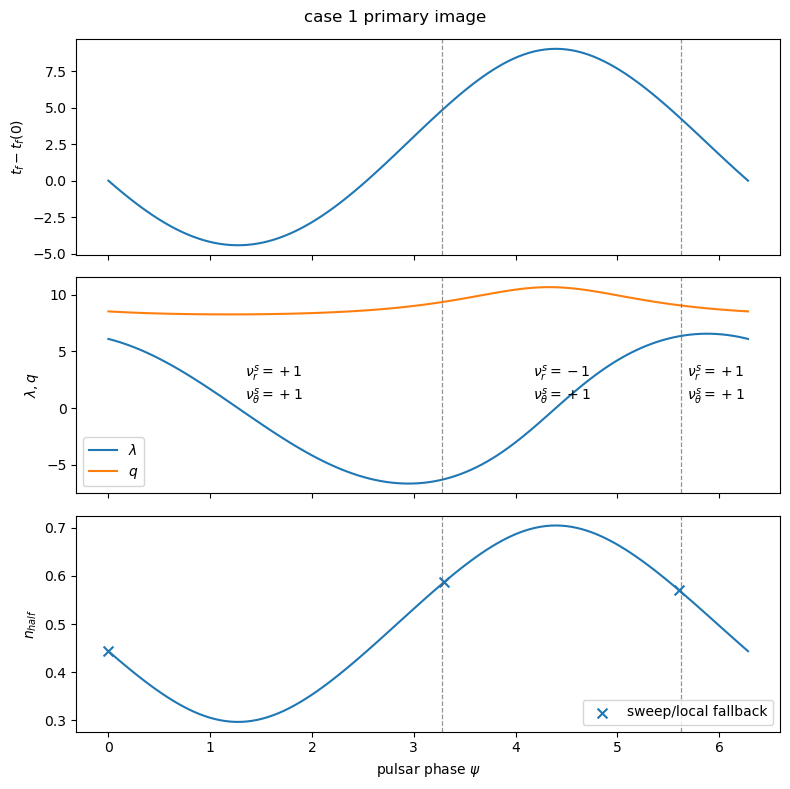

In [48]:
fig_case1 = plot_orbit_solution(case1_data, "case 1 primary image")
plt.show()

# Optional export:
# import csv
# with open("case1_primary_image.csv", "w", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=case1_data[0].keys())
#     writer.writeheader(); writer.writerows(case1_data)


## Robustness Tests: Challenging Geometries

These runnable tests cover geometries that are useful for checking the robustness of the primary-image solver.


### test 1: close inclinations

Geometry: `a=0.8`, `r_plus=1.6`, `r_s=10`, `theta_s=1.5`, `theta_o=1.51`.

Sign changes happened in both the radial and angular directions.


[00:00] initial psi=0 primary sweep: start at phi_eff=-5; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:04] initial psi=0 primary sweep: selected source=scipy_refined, n_half=0.403136, lam=10.008, q=0.820778, solutions=4 (built-in=3, refined=1), elapsed=00:04
[00:04]   0/200: psi=0.000000, phi_eff=-5.000000, method=initial_sweep_rcd_refined, success=True, n_half=0.403136, lam=10.008, q=0.820778
[00:04]  20/200: psi=0.628319, phi_eff=-5.628319, method=root_lamq, success=True, n_half=0.203574
[00:04] Branch sign changed at phi_eff = -5.75398223686: {nu_r, nu_theta} = (1, -1) -> (1, 1); method=root_lamq, n_half=0.163334
[00:04]  40/200: psi=1.256637, phi_eff=-6.256637, method=root_lamq, success=True, n_half=0.0108856
[00:04] local perturbation: start at psi=1.790708, phi_eff=-6.79070781255; reason=root failed
[00:04] local perturbation: accepted n_half=0.162659, lam=-5.0321, q=0.352466
[00:04]  57/200: psi=1.790708, phi_eff=-6.790708, method=root_lamq_local_perturb, success=True, n_half=0.16265

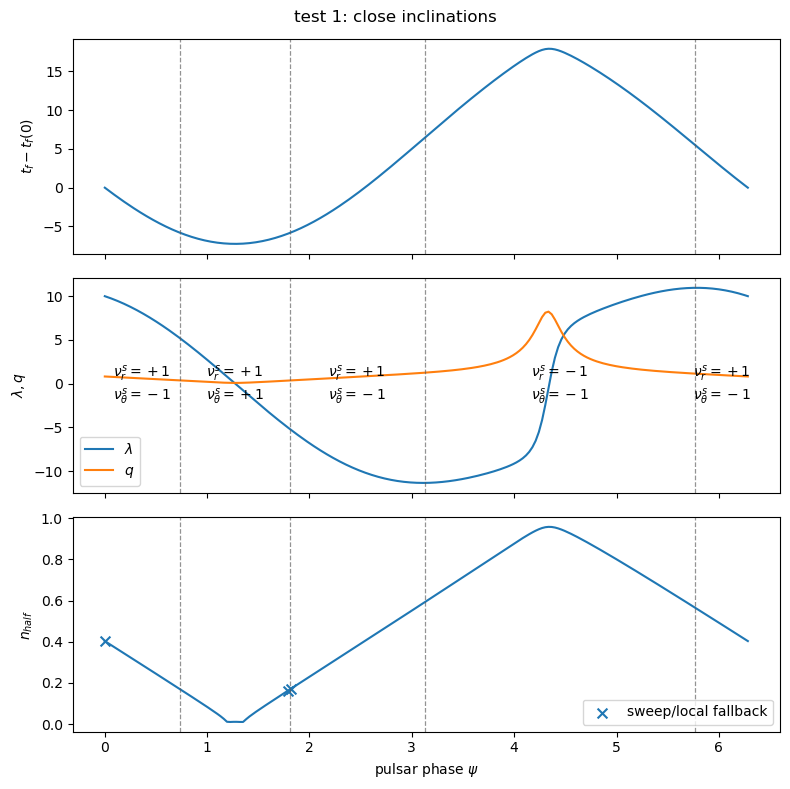

In [49]:
# Runnable test 1
test_01_geometry = OrbitConfig(**{'a': 0.8,
 'n_pts': 200,
 'phi_o': -5.0,
 'r_o': 1000.0,
 'r_s': 10.0,
 'theta_o': 1.51,
 'theta_s': 1.50})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_01_psi_sweep = sweep_orbit(test_01_geometry, my_solver_cfg, verbose=True)
fig_test_01 = plot_orbit_solution(test_01_psi_sweep, "test 1: close inclinations")
plt.show()


### test 2: axial observer

Geometry: `a=0.8`, `r_plus=1.6`, `r_s=10`, `theta_s=1.5`, `theta_o=0.001`.



[00:00] initial psi=0 primary sweep: start at phi_eff=0.78; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:02] initial psi=0 primary sweep: selected source=scipy_refined, n_half=0.477205, lam=0.00751832, q=10.831, solutions=3 (built-in=0, refined=3), elapsed=00:02
[00:02]   0/24: psi=0.000000, phi_eff=0.780000, method=initial_sweep_rcd_refined, success=True, n_half=0.477205, lam=0.00751832, q=10.831
[00:02] local perturbation: start at psi=1.047198, phi_eff=-0.267197551197; reason=n_half jump: 0.477116 -> 1.52289
[00:02] local perturbation: accepted n_half=0.477129, lam=-0.0030289, q=10.8306
[00:02]   4/24: psi=1.047198, phi_eff=-0.267198, method=root_lamq_local_perturb, success=True, n_half=0.477129, reason=n_half jump: 0.477116 -> 1.52289
[00:02] local perturbation: start at psi=1.832596, phi_eff=-1.05259571459; reason=root failed
[00:03] local perturbation: accepted n_half=0.477281, lam=-0.00951754, q=10.8317
[00:03]   7/24: psi=1.832596, phi_eff=-1.052596, method=root_lamq_local_perturb, 

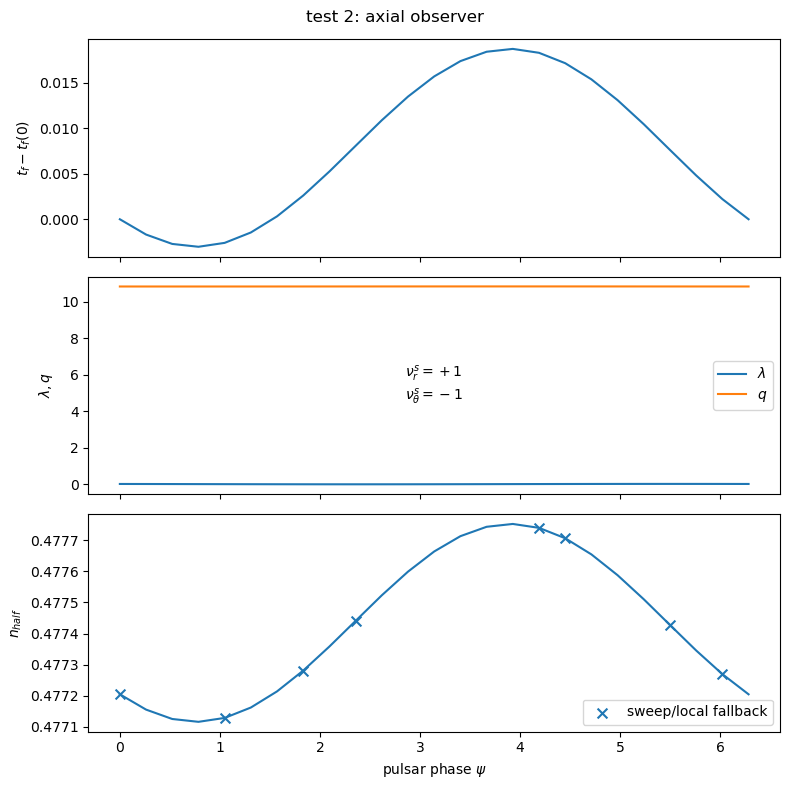

In [50]:
# Runnable test 2
test_02_geometry = OrbitConfig(**{'a': 0.8,
 'n_pts': 24,
 'phi_o': 0.78,
 'r_o': 1000.0,
 'r_s': 10.0,
 'theta_o': 0.001,
 'theta_s': 1.5})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_02_psi_sweep = sweep_orbit(test_02_geometry, my_solver_cfg, verbose=True)
fig_test_02 = plot_orbit_solution(test_02_psi_sweep, "test 2: axial observer")
plt.show()


### test 3: near-extremal spin

Geometry: `a=0.999`, `r_plus=1.04471017781`, `r_s=6`, `theta_s=1.4`, `theta_o=1.3`.



[00:00] initial psi=0 primary sweep: start at phi_eff=-1.2; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:05] initial psi=0 primary sweep: selected source=builtin, n_half=0.386752, lam=-6.0612, q=1.74415, solutions=32 (built-in=3, refined=29), elapsed=00:05
[00:05]   0/100: psi=0.000000, phi_eff=-1.200000, method=initial_sweep_rcd, success=True, n_half=0.386752, lam=-6.0612, q=1.74415
[00:05] local perturbation: start at psi=1.130973, phi_eff=-2.33097335529; reason=root failed
[00:05] local perturbation: accepted n_half=0.738447, lam=-6.57588, q=4.30465
[00:05] Branch sign changed at phi_eff = -2.33097335529: {nu_r, nu_theta} = (1, -1) -> (-1, -1); method=root_lamq_local_perturb, n_half=0.738447
[00:05]  18/100: psi=1.130973, phi_eff=-2.330973, method=root_lamq_local_perturb, success=True, n_half=0.738447, reason=root failed
[00:05]  20/100: psi=1.256637, phi_eff=-2.456637, method=root_lamq, success=True, n_half=0.773193
[00:05]  40/100: psi=2.513274, phi_eff=-3.713274, method=root_lamq, suc

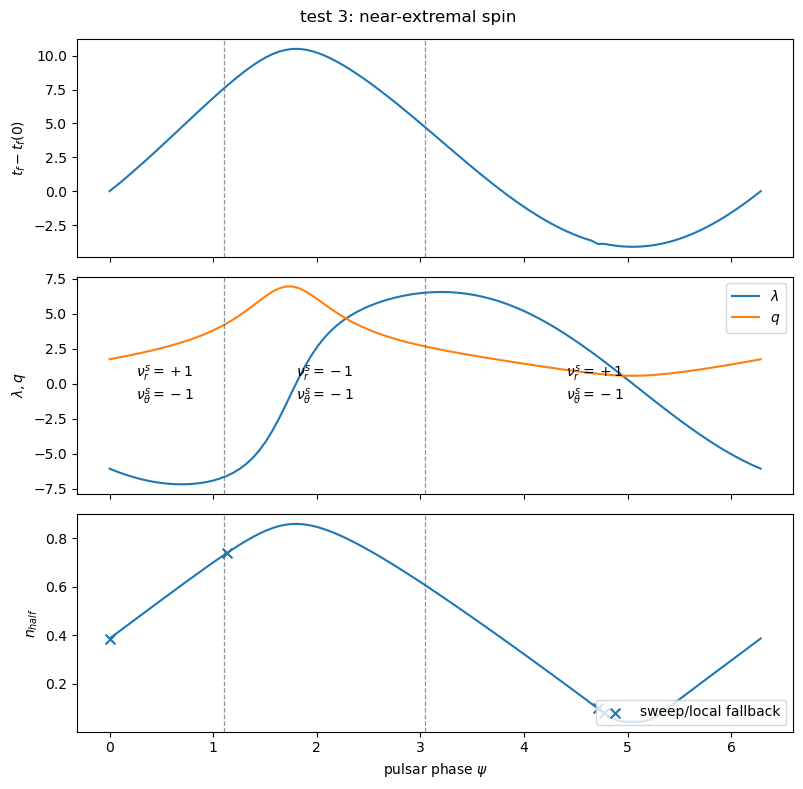

In [51]:
# Runnable test 3
test_03_geometry = OrbitConfig(**{'a': 0.999,
 'n_pts': 100,
 'phi_o': -1.2,
 'r_o': 1000.0,
 'r_s': 6.0,
 'theta_o': 1.3,
 'theta_s': 1.4})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_03_psi_sweep = sweep_orbit(test_03_geometry, my_solver_cfg, verbose=True)
fig_test_03 = plot_orbit_solution(test_03_psi_sweep, "test 3: near-extremal spin")
plt.show()


### test 4: near horizon

Geometry: `a=0.5`, `r_plus=1.86602540378`, `r_s=1.87`, `theta_s=2.53`, `theta_o=2.81`.



[00:00] initial psi=0 primary sweep: start at phi_eff=1.1; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:03] initial psi=0 primary sweep: selected source=builtin, n_half=0.0894591, lam=-0.143634, q=0.424706, solutions=3 (built-in=3, refined=0), elapsed=00:03
[00:03]   0/24: psi=0.000000, phi_eff=1.100000, method=initial_sweep_rcd, success=True, n_half=0.0894591, lam=-0.143634, q=0.424706
[00:03]  20/24: psi=5.235988, phi_eff=-4.135988, method=root_lamq, success=True, n_half=0.112093
[00:03]  24/24: psi=6.283185, phi_eff=-5.183185, method=root_lamq, success=True, n_half=0.0894591


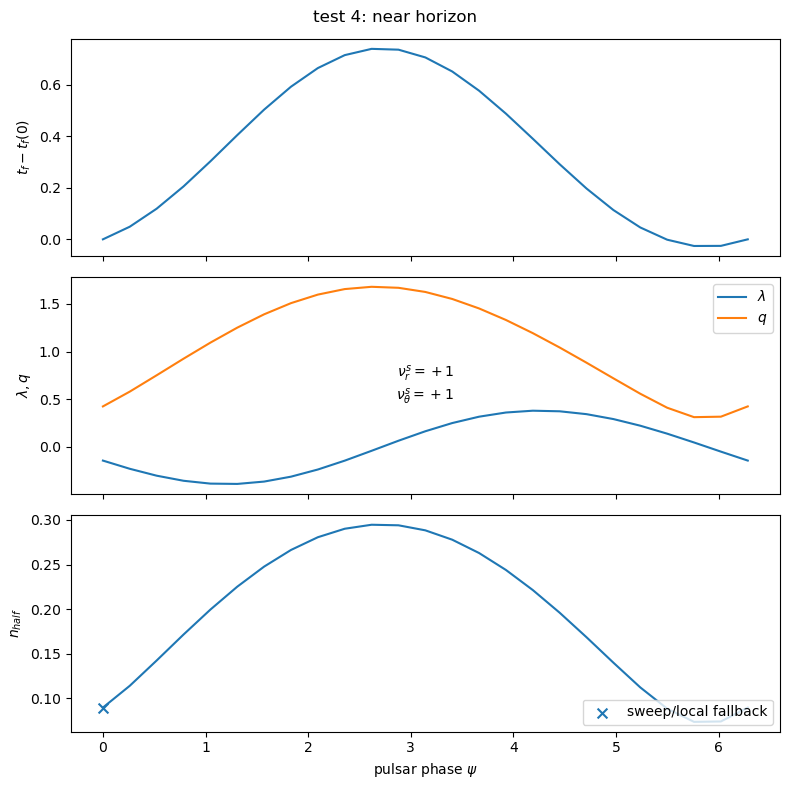

In [52]:
# Runnable test 4
test_04_geometry = OrbitConfig(**{'a': 0.5,
 'n_pts': 24,
 'phi_o': 1.1,
 'r_o': 1000.0,
 'r_s': 1.87,
 'theta_o': 2.81,
 'theta_s': 2.53})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_04_psi_sweep = sweep_orbit(test_04_geometry, my_solver_cfg, verbose=True)
fig_test_04 = plot_orbit_solution(test_04_psi_sweep, "test 4: near horizon")
plt.show()

### test 5: large source radius

Geometry: `a=0.8`, `r_plus=1.6`, `r_s=500`, `theta_s=0.349065850399`, `theta_o=0.174532925199`.

If `r_s` is large, make sure `log_abs_d_max` is large enough to capture the primary image.


[00:00] initial psi=0 primary sweep: start at phi_eff=-2.5; grid=500x500, log_abs_d=[-3.0, 3.0]
[00:10] initial psi=0 primary sweep: selected source=builtin, n_half=0.158987, lam=-29.1518, q=391.745, solutions=4 (built-in=3, refined=1), elapsed=00:10
[00:10]   0/24: psi=0.000000, phi_eff=-2.500000, method=initial_sweep_rcd, success=True, n_half=0.158987, lam=-29.1518, q=391.745
[00:10]  20/24: psi=5.235988, phi_eff=-7.735988, method=root_lamq, success=True, n_half=0.117704
[00:10]  24/24: psi=6.283185, phi_eff=-8.783185, method=root_lamq, success=True, n_half=0.158987


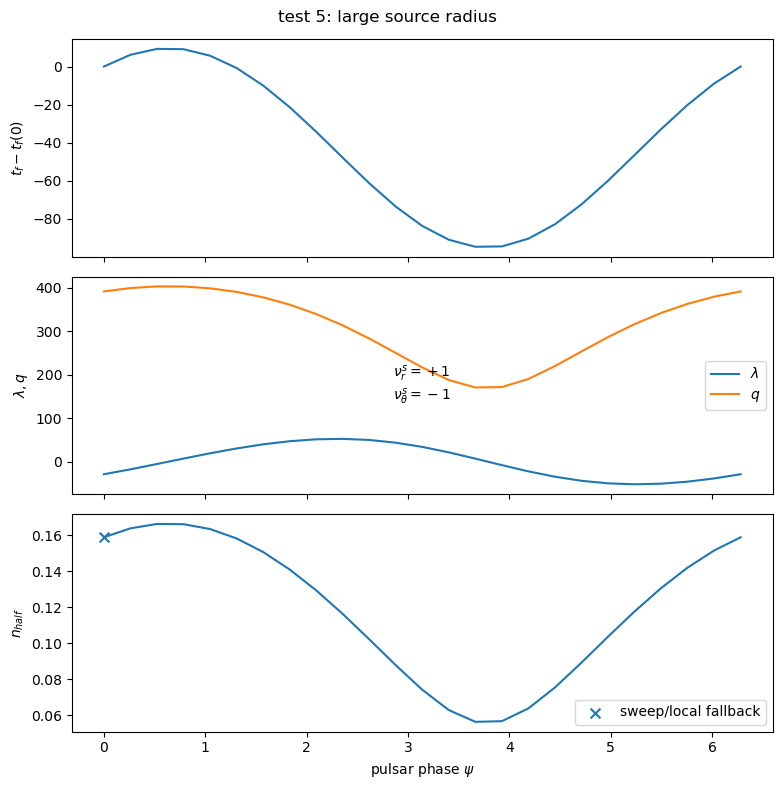

In [60]:
# Runnable test 5
test_05_geometry = OrbitConfig(**{'a': 0.8,
 'n_pts': 24,
 'phi_o': -2.5,
 'r_o': 1000.0,
 'r_s': 500.0,
 'theta_o': 0.17453292519943295,
 'theta_s': 0.3490658503988659})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_05_psi_sweep = sweep_orbit(test_05_geometry, my_solver_cfg, verbose=True)
fig_test_05 = plot_orbit_solution(test_05_psi_sweep, "test 5: large source radius")
plt.show()


### test 6: avoid jumping to the lensed (n_half>1) branch

Geometry: `a=0.01`, `r_plus=1.99994999875`, `r_s=2.01`, `theta_s=1.5`, `theta_o=1.6`.

Increased `rc_size` and `d_size` in order to detect the primary image.

Decreased `max_nhalf_jump` to avoid jumping to the first-lensed image branch (`n_half>1`) around psi=1.8. This is crucial if `n_half` approaches 1 somewhere.


[00:00] initial psi=0 primary sweep: start at phi_eff=-2.5; grid=1000x1000, log_abs_d=[-3.0, 3.0]
[00:02] initial psi=0 primary sweep: selected source=scipy_refined, n_half=0.803618, lam=-3.99606, q=0.34575, solutions=3 (built-in=0, refined=3), elapsed=00:02
[00:02]   0/200: psi=0.000000, phi_eff=-2.500000, method=initial_sweep_rcd_refined, success=True, n_half=0.803618, lam=-3.99606, q=0.34575
[00:02] local perturbation: start at psi=0.628319, phi_eff=-3.12831853072; reason=n_half jump: 0.985598 -> 1.01395
[00:02] local perturbation: accepted n_half=0.986074, lam=1.37404, q=4.21732
[00:02]  20/200: psi=0.628319, phi_eff=-3.128319, method=root_lamq_local_perturb, success=True, n_half=0.986074, reason=n_half jump: 0.985598 -> 1.01395
[00:02] local perturbation: start at psi=0.659734, phi_eff=-3.15973445725; reason=root failed
[00:03] local perturbation: accepted n_half=0.98052, lam=3.2371, q=3.00776
[00:03]  21/200: psi=0.659734, phi_eff=-3.159734, method=root_lamq_local_perturb, succes

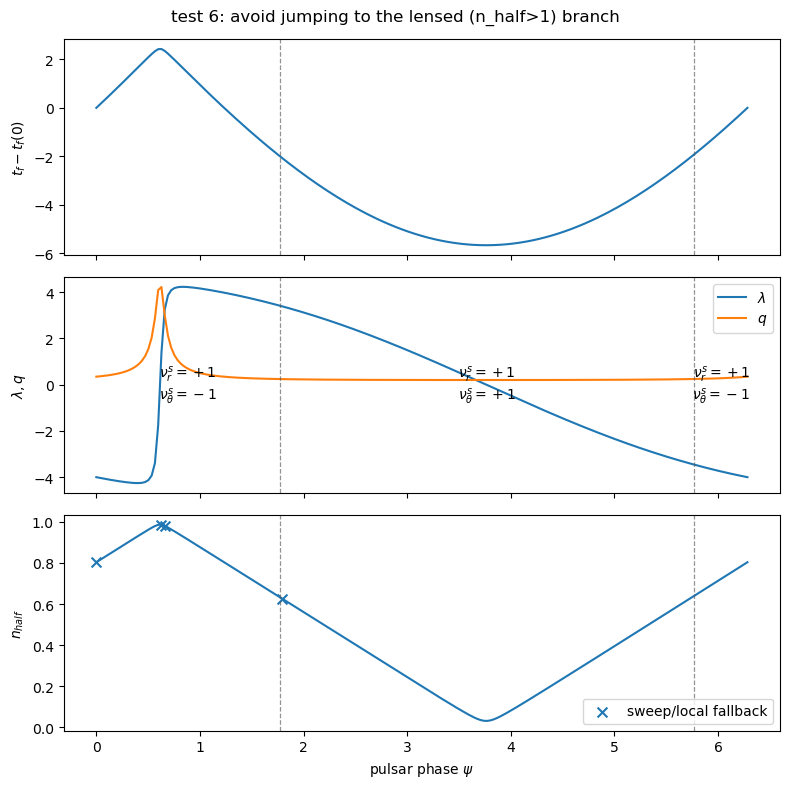

In [68]:
# Runnable test 6
test_06_geometry = OrbitConfig(**{'a': 0.01,
 'n_pts': 200,
 'phi_o': -2.5,
 'r_o': 1000.0,
 'r_s': 2.01,
 'theta_o': 1.6,
 'theta_s': 1.5})

my_solver_cfg = SolverConfig(
    rc_size=500,
    d_size=500,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.1,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_06_solver_cfg = SolverConfig(
    rc_size=1000,
    d_size=1000,
    log_abs_d_min=-3.0,
    log_abs_d_max=3.0,
    sweep_refine_max_candidates=10,
    max_nhalf_jump=0.02,
    cutoff=50,
    tol_sweep=1e-6,
    tol_sweep_refine=1e-6,
    tol_root=1e-6,
)

test_06_psi_sweep = sweep_orbit(test_06_geometry, test_06_solver_cfg, verbose=True)
fig_test_06 = plot_orbit_solution(test_06_psi_sweep, "test 6: avoid jumping to the lensed (n_half>1) branch")
plt.show()
